In [125]:
'''
Simple MPL
Autor: Maria Hadam
28.06.2026
Edited: Ziemowit Olinkiewicz
20.07.2026
'''

import json
import torch
import sys
sys.path.append("./source")

import model as mlp
import numpy as np
import lindblad_solver as solver
import dataset as ds
import training as t
import plotting as plt
import matplotlib.pyplot as mpl
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

In [2]:
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
True


In [107]:
# Load the dataset

root_train = "data/dataset_20ps_narrow_5000t"     # name of the dataset directory
root_test = "data/dataset_20ps_mid_5000t"     # name of the dataset directory
# root = "data/dataset_2_rel40_decoh20_5000t"

dataset = ds.TrajectoryDataset(root_train, False)
x, y, rho_t, rho_tp1 = dataset[0]                # load the first trajectory
print(f"number of trajectories: {len(dataset)}")
print(f"feature shape (input): {x.shape}  (n_steps+1={dataset._n_steps_plus_1}, 32 per step)")
print(f"label shape: {y.shape}  -> {ds.TAU_KEYS}")
print(f"label of the first trajectory (log-tau): {y}")
print(f"rho_t shape: {rho_t.shape}, rho_tp1 shape: {rho_tp1.shape}  (random consecutive pair)")
print()

# Preprocessing: prepare the dataset for training
train_ds, val_ds, test_ds = ds.split_dataset(dataset)   # split into train/val/test
print(f"split sizes: train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

mean, std, labels = ds.compute_label_stats(dataset, train_ds.indices)
print(f"train label mean: {mean}")
print(f"train label std:  {std}")
#print(f"train label:  {labels}")

number of trajectories: 5000
feature shape (input): torch.Size([640])  (n_steps+1=401, 32 per step)
label shape: torch.Size([5])  -> ['tau_relax1', 'tau_relax2', 'tau_deph1', 'tau_deph2', 'tau_cordeph']
label of the first trajectory (log-tau): tensor([3.0947, 3.1231, 2.7781, 3.1128, 3.1049])
rho_t shape: torch.Size([10, 4, 4]), rho_tp1 shape: torch.Size([10, 4, 4])  (random consecutive pair)

split sizes: train=3500 val=750 test=750
train label mean: tensor([2.9873, 2.9926, 2.9870, 2.9872, 2.9875])
train label std:  tensor([0.1163, 0.1160, 0.1160, 0.1152, 0.1174])


In [7]:
input_dim = dataset.feature_dim
output_dim = 5
model = mlp.MLP(input_dim, output_dim, hidden_dims=[1024, 512, 256, 128, 64, 32], activation='relu', use_batchnorm=True, dropout_rate=0.2)
print(model)

dummy_x = torch.randn(8, input_dim)  # batch of 8
out = model(dummy_x)
print("output shape:", out.shape)  # expect (8, 5)
assert out.shape == (8, output_dim)
print("OK")

MLP(
  (model): Sequential(
    (0): Linear(in_features=640, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=128, out_features=64, bias=True)
    (17): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_run

dataset size: 5000  (train=3500, val=750, test=750)
train label (log-tau) mean: tensor([2.9873, 2.9926, 2.9870, 2.9872, 2.9875])
train label (log-tau) std:  tensor([0.1163, 0.1160, 0.1160, 0.1152, 0.1174])
data=4.937s, validation=3.146s, 
epoch 000 | lambda_phys=0.000 | train: total=4.8102e+00 data=4.8102e+00 phys=1.2586e-04 | val: total=1.8416e+00 data=1.8416e+00 phys=1.7211e-07
  -> new best val loss, checkpoint saved to best_pinn_dataset1.pt
  -> new best val loss, checkpoint saved to best_pinn_dataset1.pt
  -> new best val loss, checkpoint saved to best_pinn_dataset1.pt
  -> new best val loss, checkpoint saved to best_pinn_dataset1.pt
  -> new best val loss, checkpoint saved to best_pinn_dataset1.pt
  -> new best val loss, checkpoint saved to best_pinn_dataset1.pt
  -> new best val loss, checkpoint saved to best_pinn_dataset1.pt
  -> new best val loss, checkpoint saved to best_pinn_dataset1.pt
  -> new best val loss, checkpoint saved to best_pinn_dataset1.pt
data=0.289s, validation

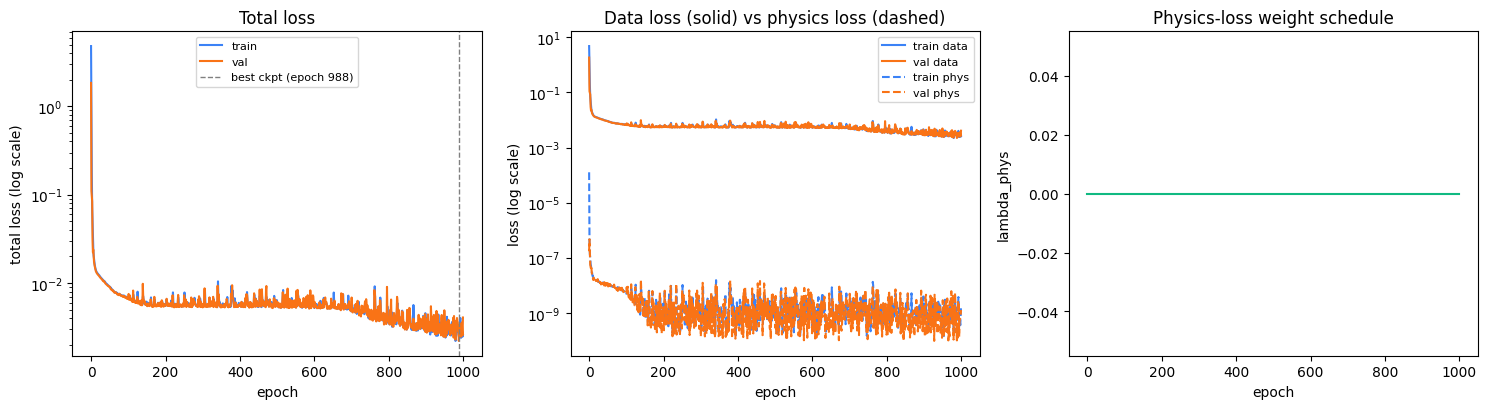

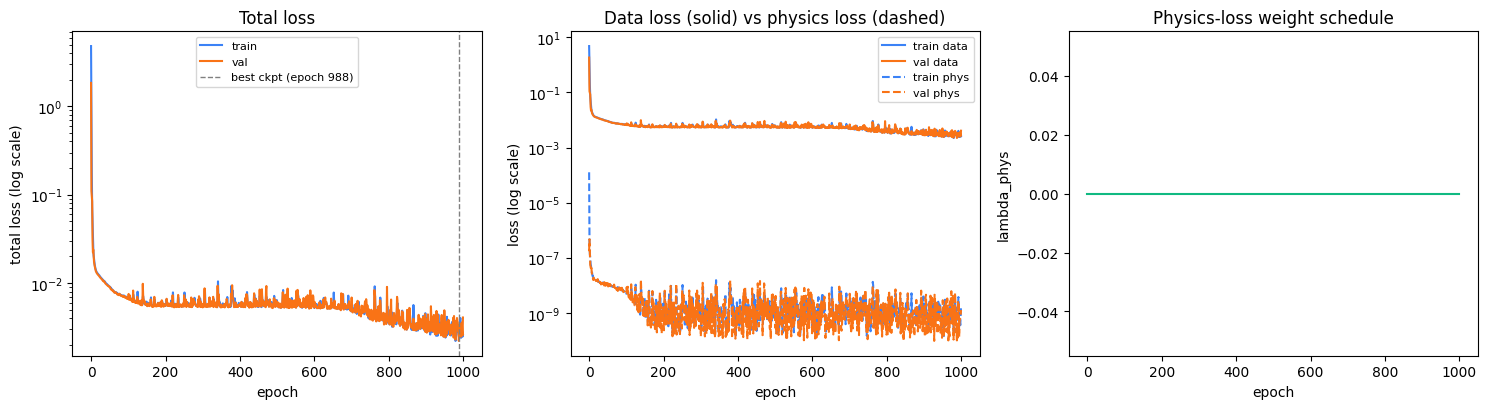

In [9]:
pinn, dataset, (train_ds, val_ds, test_ds), history = t.train_pinn(
    root=root_train,
    n_epochs=1000,
    batch_size=512 ,#64,
    lr=1e-3,
    warmup_epochs=10,
    min_lambda_phys=0,#1e4,
    max_lambda_phys=0,#1e8,
    lambda_data=1.0,
    hidden_dims=(1024, 512, 256, 128, 64, 32),
    num_workers=1,
    preloaddata=True,
    checkpoint_path="best_pinn_dataset1.pt",
    seed=0,
)

print("Training complete. Best checkpoint loaded.")

# save history so you can replot later without retraining
import json
with open("history_dataset1.json", "w") as f:
    json.dump(history, f)

plt.plot_history(history, save_path="pinn_training_dataset3.png")

In [109]:
#kawalek kodu do wyciagania wynikow z ML i porownywania z prawdziwymi labelkami
device = "cuda" if torch.cuda.is_available() else "cpu"

labels_true = []
labels_pred = []
labels_train_true = []
labels_train_pred = []
dataset_test = ds.TrajectoryDataset(root_test, False)
testlen = len(dataset_test.files)
trainlen = len(dataset.files)
for i in range(testlen):
    features, labels, rho_t, rho_tp1 = dataset_test.__getitem__(i)
    features = features.to(device)
    taus_pred_log, taus_pred, gammas_pred = pinn.forward(features)
    labels_true.append(torch.exp(labels).detach().cpu().numpy())
    labels_pred.append(taus_pred.detach().cpu().numpy())

for i in range(trainlen):
    features, labels, rho_t, rho_tp1 = dataset.__getitem__(i)
    features = features.to(device)
    taus_pred_log, taus_pred, gammas_pred = pinn.forward(features)
    labels_train_true.append(torch.exp(labels).detach().cpu().numpy())
    labels_train_pred.append(taus_pred.detach().cpu().numpy())


labels_true = np.array(labels_true)
labels_pred = np.array(labels_pred)
labels_train_true = np.array(labels_train_true)
labels_train_pred = np.array(labels_train_pred)


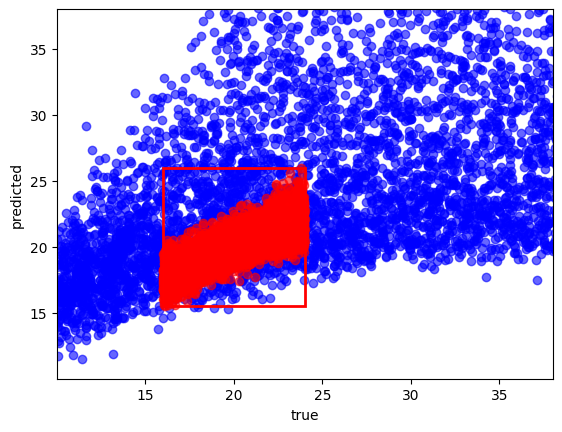

[16.520414 19.320429 25.758    32.995934 12.773501]
[16.77279  19.77008  19.359428 18.489998 15.189225]


In [110]:

col = 2 #0,1 - relax; 2,3 - dephas; 4 - cor dephas

vals = np.concatenate([labels_true[:, col], labels_pred[:, col]])
vals_train_true = np.concatenate([labels_train_true[:, col]])
vals_train_pred = np.concatenate([labels_train_pred[:, col]])
max_val = np.sort(vals)[int(len(vals)*9/10)-1]
min_val = np.sort(vals)[0]
max_val_train_true = np.sort(vals_train_true)[len(vals_train_true)-1]
min_val_train_true = np.sort(vals_train_true)[0]
max_val_train_pred = np.sort(vals_train_pred)[len(vals_train_pred)-1]
min_val_train_pred = np.sort(vals_train_pred)[0]


mpl.scatter(labels_true[:, col], labels_pred[:, col], color='blue', alpha=0.6)
mpl.scatter(labels_train_true[:, col], labels_train_pred[:, col], color='red', alpha=0.6)
mpl.xlabel("true")
mpl.ylabel("predicted")
mpl.xlim(min_val, max_val)
mpl.ylim(min_val, max_val)
ax = mpl.gca()
ax.add_patch(Rectangle((min_val_train_true, min_val_train_pred), max_val_train_true-min_val_train_true, max_val_train_pred-min_val_train_pred,
                       fill=False, edgecolor='red', linewidth=2))
mpl.show()

num = 57
print(labels_true[num, :])
print(labels_pred[num, :])

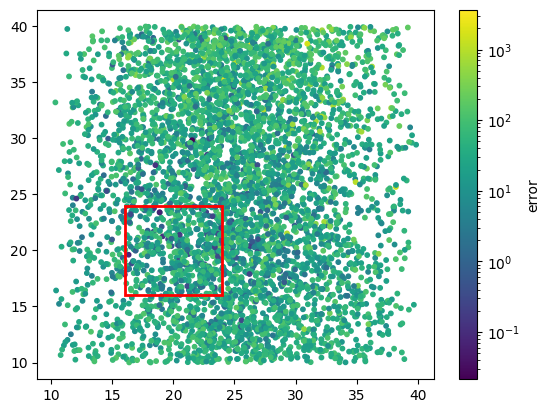

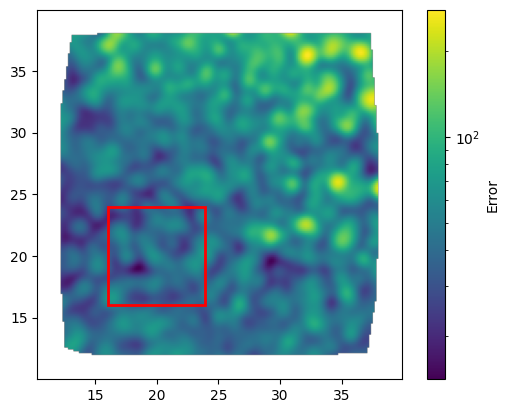

In [141]:
x_cols = [0,1]
y_cols = [2]
error_cols = [2,3,4]

xaxis = labels_true[:, x_cols].mean(axis=1)
yaxis = labels_true[:, y_cols].mean(axis=1)

xmin = np.min(labels_train_true[:, x_cols].mean(axis=1))
ymin = np.min(labels_train_true[:, y_cols].mean(axis=1))
xmax = np.max(labels_train_true[:, x_cols].mean(axis=1))
ymax = np.max(labels_train_true[:, y_cols].mean(axis=1))

error = np.mean((labels_pred[:, error_cols] - labels_true[:, error_cols])**2, axis=1)

mpl.scatter(xaxis, yaxis, c=error, cmap='viridis', s=10, norm=LogNorm())
mpl.colorbar(label='error')
ax = mpl.gca()
ax.add_patch(Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                       fill=False, edgecolor='red', linewidth=2))
mpl.show()



grid_x, grid_y = np.mgrid[
    xaxis.min():xaxis.max():200j,
    yaxis.min():yaxis.max():200j
]

grid_z = griddata((xaxis, yaxis), error, (grid_x, grid_y), method='linear')
grid_z = gaussian_filter(grid_z, sigma=3)

mpl.imshow(
    grid_z.T,
    origin='lower',
    extent=(xaxis.min(), xaxis.max(), yaxis.min(), yaxis.max()),
    cmap='viridis',
    aspect='equal',
    norm=LogNorm()
)
ax = mpl.gca()
ax.add_patch(Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                       fill=False, edgecolor='red', linewidth=2))
mpl.colorbar(label='Error')
mpl.show()

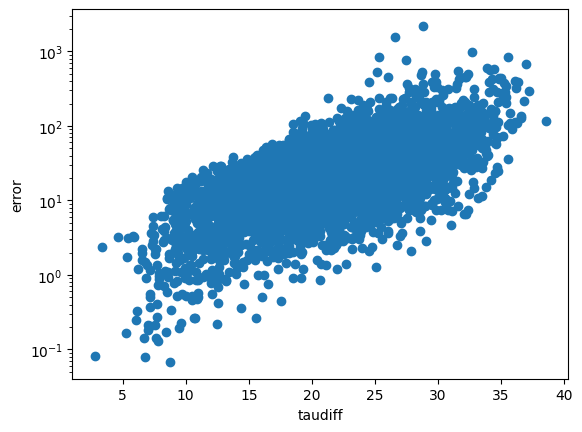

In [112]:
diff_cols = [0,1,2,3,4]
taudiff = np.sqrt(((labels_true[:,diff_cols]-20)**2).sum(axis=1))

mpl.scatter(taudiff, error)
mpl.yscale('log')      # oś X logarytmiczna
mpl.xlabel("taudiff")
mpl.ylabel("error")
mpl.show()